In [2]:
%matplotlib inline
import sys
!{sys.executable} -m pip install matplotlib seaborn pymysql pandas --quiet

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pymysql

# consistent style across all 4 charts
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"]      = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# reusable connection function — change password to yours
def get_connection():
    return pymysql.connect(
        host="localhost",
        user="root",
        password="valorant1",
        database="olist_analysis"
    )

print("Ready")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\kumar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Ready


In [3]:
conn = get_connection()

monthly = pd.read_sql("""
    SELECT
        DATE_FORMAT(order_purchase_timestamp, '%Y-%m') AS order_month,
        COUNT(order_id)                                AS total_orders
    FROM olist_orders
    WHERE order_status = 'delivered'
      AND order_purchase_timestamp >= '2017-01-01'
      AND order_purchase_timestamp <  '2018-09-01'
    GROUP BY order_month
    ORDER BY order_month
""", conn)

conn.close()

# convert month string to datetime so matplotlib plots it correctly on x-axis
monthly["order_month"] = pd.to_datetime(monthly["order_month"])

# calculate MoM growth %
monthly["mom_growth"] = monthly["total_orders"].pct_change() * 100

print(monthly.to_string(index=False))

C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\1617362963.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly = pd.read_sql("""


order_month  total_orders  mom_growth
 2017-01-01           750         NaN
 2017-02-01          1653  120.400000
 2017-03-01          2546   54.022989
 2017-04-01          2303   -9.544383
 2017-05-01          3546   53.973079
 2017-06-01          3135  -11.590525
 2017-07-01          3872   23.508772
 2017-08-01          4193    8.290289
 2017-09-01          4150   -1.025519
 2017-10-01          4478    7.903614
 2017-11-01          7289   62.773560
 2017-12-01          5513  -24.365482
 2018-01-01          7069   28.224197
 2018-02-01          6555   -7.271184
 2018-03-01          7003    6.834477
 2018-04-01          6798   -2.927317
 2018-05-01          6749   -0.720800
 2018-06-01          6099   -9.631056
 2018-07-01          6159    0.983768
 2018-08-01          6351    3.117389


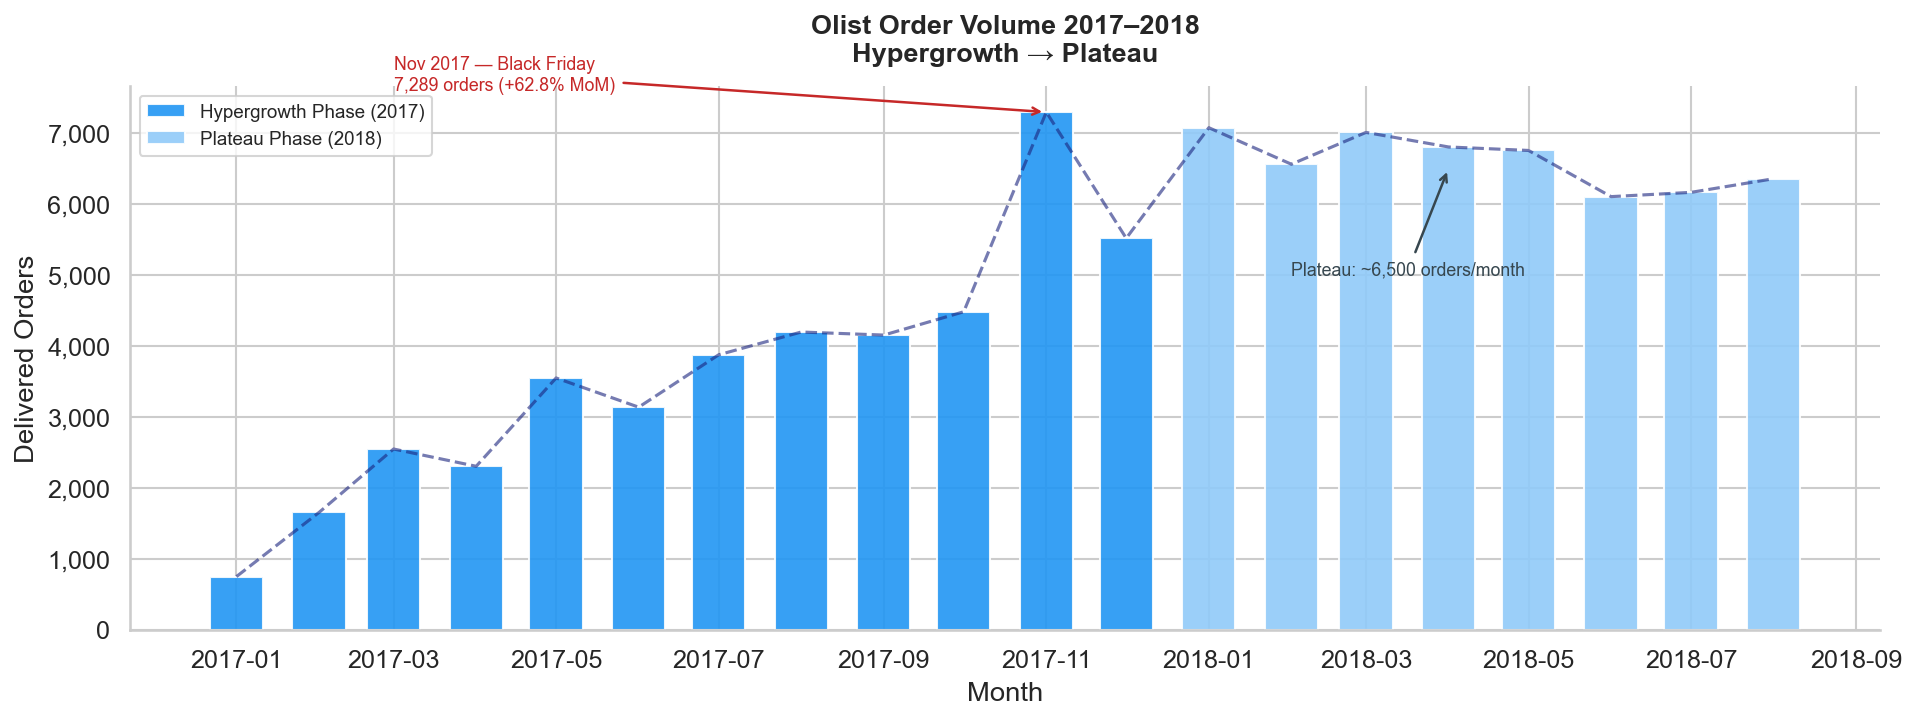

In [4]:
# split into two phases based on our SQL finding
growth_phase  = monthly[monthly["order_month"] <  "2018-01-01"]
plateau_phase = monthly[monthly["order_month"] >= "2018-01-01"]

fig, ax = plt.subplots(figsize=(13, 5))

# growth phase bars — stronger blue
ax.bar(growth_phase["order_month"],  growth_phase["total_orders"],
       width=20, color="#2196F3", alpha=0.9, label="Hypergrowth Phase (2017)")

# plateau phase bars — muted grey-blue
ax.bar(plateau_phase["order_month"], plateau_phase["total_orders"],
       width=20, color="#90CAF9", alpha=0.9, label="Plateau Phase (2018)")

# overlay the actual order count as a trend line
ax.plot(monthly["order_month"], monthly["total_orders"],
        color="#1A237E", linewidth=1.5, linestyle="--", alpha=0.6)

# format y-axis with commas
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# annotate two key moments
ax.annotate("Nov 2017 — Black Friday\n7,289 orders (+62.8% MoM)",
    xy=(pd.Timestamp("2017-11-01"), 7289),
    xytext=(pd.Timestamp("2017-03-01"), 7600),
    fontsize=8.5, color="#C62828",
    arrowprops=dict(arrowstyle="->", color="#C62828", lw=1.2))

ax.annotate("Plateau: ~6,500 orders/month",
    xy=(pd.Timestamp("2018-04-01"), 6500),
    xytext=(pd.Timestamp("2018-02-01"), 5000),
    fontsize=8.5, color="#37474F",
    arrowprops=dict(arrowstyle="->", color="#37474F", lw=1.2))

ax.set_xlabel("Month")
ax.set_ylabel("Delivered Orders")
ax.set_title("Olist Order Volume 2017–2018\nHypergrowth → Plateau",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("chart1_growth.png", bbox_inches="tight")
plt.show()


In [5]:
print("\nStory 1 Finding:")
print("Olist grew 10x Jan→Nov 2017 (750 → 7,289 orders).")
print("Business plateaued at ~6,500/month from Jan 2018 onwards.")
print("Growth was acquisition-driven — retention data (Story 4) explains why.")


Story 1 Finding:
Olist grew 10x Jan→Nov 2017 (750 → 7,289 orders).
Business plateaued at ~6,500/month from Jan 2018 onwards.
Growth was acquisition-driven — retention data (Story 4) explains why.


In [6]:
conn = get_connection()

delivery = pd.read_sql("""
    SELECT
        c.customer_state                                      AS region,
        COUNT(DISTINCT o.order_id)                           AS total_orders,
        ROUND(AVG(DATEDIFF(
            o.order_delivered_customer_date,
            o.order_purchase_timestamp)), 1)                 AS avg_delivery_days,
        ROUND(AVG(r.review_score), 2)                        AS avg_review_score
    FROM olist_orders o
    JOIN olist_customers c       ON o.customer_id    = c.customer_id
    JOIN olist_order_reviews r   ON o.order_id       = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY c.customer_state
    HAVING COUNT(DISTINCT o.order_id) > 100
""", conn)

conn.close()

print(delivery.sort_values("avg_delivery_days", ascending=False).to_string(index=False))

C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\2719991227.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  delivery = pd.read_sql("""


region  total_orders  avg_delivery_days  avg_review_score
    AM           144               26.2              4.22
    AL           394               24.4              3.84
    PA           933               23.6              3.91
    SE           334               21.4              3.91
    MA           712               21.3              3.84
    CE          1273               21.1              3.94
    PB           512               20.2              4.08
    PI           471               19.4              4.00
    RO           242               19.3              4.17
    RN           471               19.2              4.15
    BA          3229               19.2              3.93
    PE          1579               18.3              4.09
    MT           879               17.9              4.15
    TO           273               17.6              4.15
    ES          1969               15.6              4.08
    MS           699               15.6              4.17
    GO        

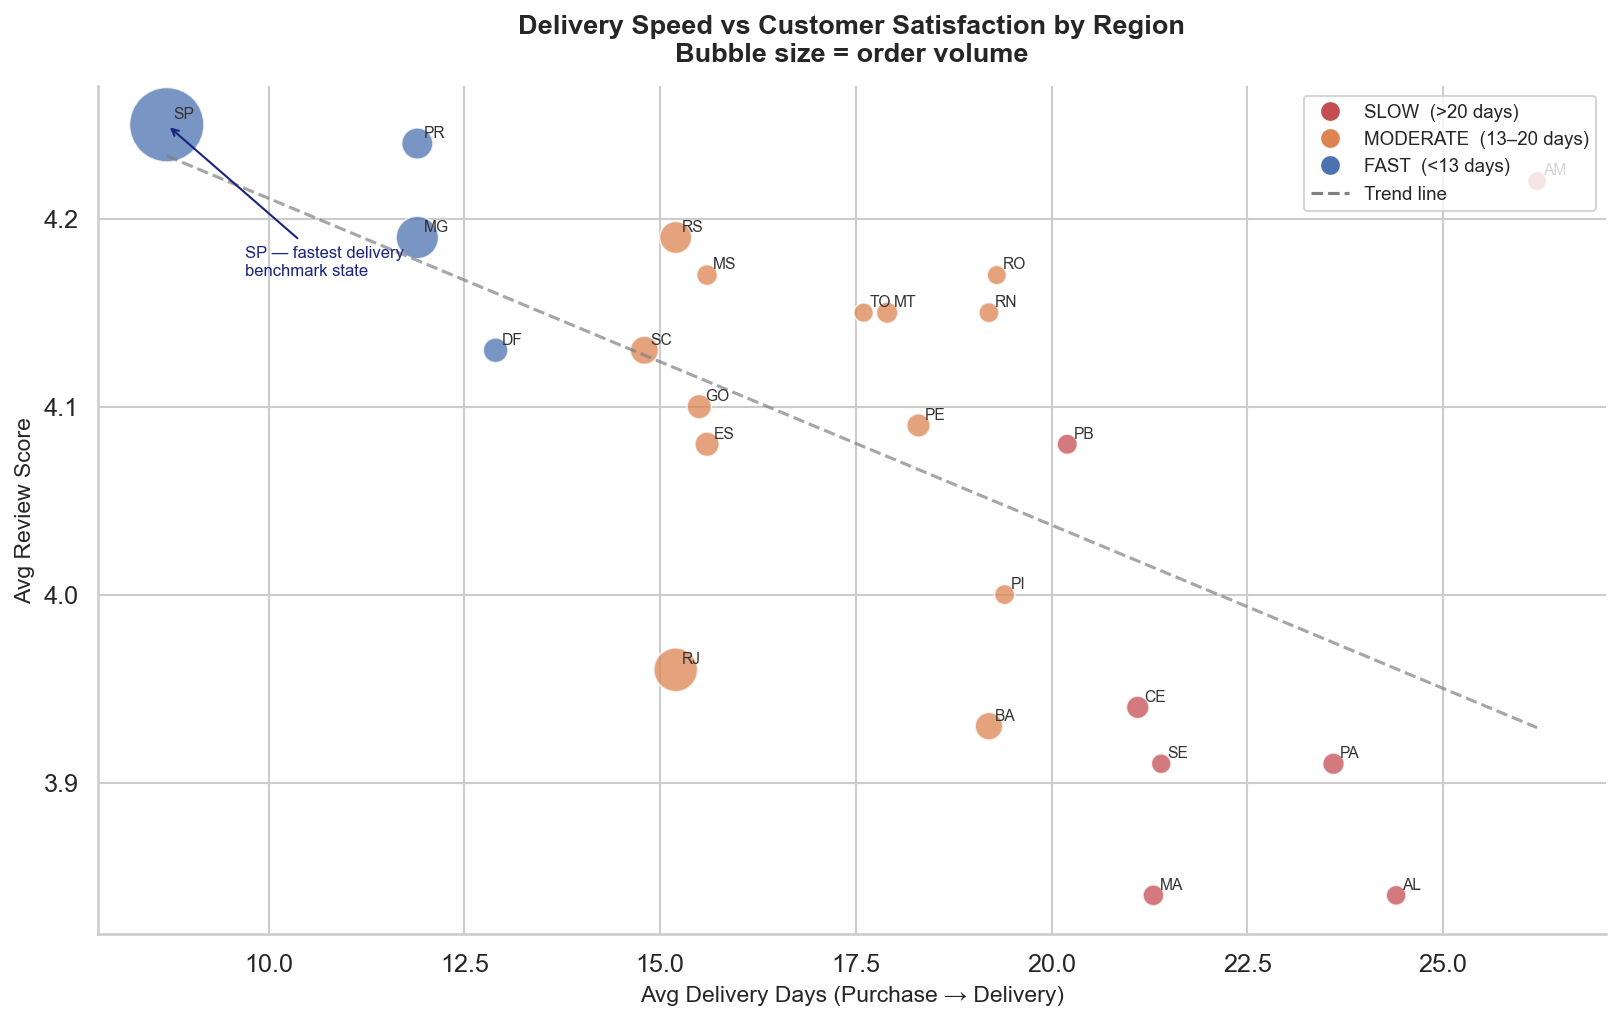

In [7]:
fig, ax = plt.subplots(figsize=(11, 7))

# colour states by delivery band — same bands as SQL Query 3
def delivery_color(days):
    if days > 20:   return "#C44E52"    # red — SLOW
    elif days > 13: return "#DD8452"    # orange — MODERATE
    else:           return "#4C72B0"    # blue — FAST

colors = delivery["avg_delivery_days"].apply(delivery_color)

# bubble size = order volume — bigger bubble = more customers affected
bubble_sizes = (delivery["total_orders"] / delivery["total_orders"].max()) * 1200 + 80

scatter = ax.scatter(
    delivery["avg_delivery_days"],
    delivery["avg_review_score"],
    s=bubble_sizes,
    c=colors,
    alpha=0.75,
    edgecolors="white",
    linewidth=0.8
)

# label every state bubble
for _, row in delivery.iterrows():
    ax.annotate(
        row["region"],
        xy=(row["avg_delivery_days"], row["avg_review_score"]),
        xytext=(3, 3), textcoords="offset points",
        fontsize=7.5, color="#333333"
    )

# add a trend line to make correlation visible
import numpy as np
z = np.polyfit(delivery["avg_delivery_days"], delivery["avg_review_score"], 1)
p = np.poly1d(z)
x_line = np.linspace(delivery["avg_delivery_days"].min(),
                     delivery["avg_delivery_days"].max(), 100)
ax.plot(x_line, p(x_line),
        color="gray", linewidth=1.5,
        linestyle="--", alpha=0.7, label="Trend line")

# legend for delivery bands
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C44E52',
           markersize=10, label='SLOW  (>20 days)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#DD8452',
           markersize=10, label='MODERATE  (13–20 days)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0',
           markersize=10, label='FAST  (<13 days)'),
    Line2D([0], [0], color='gray', linewidth=1.5,
           linestyle='--', label='Trend line'),
]
ax.legend(handles=legend_elements, fontsize=9, loc="upper right")

ax.set_xlabel("Avg Delivery Days (Purchase → Delivery)", fontsize=11)
ax.set_ylabel("Avg Review Score", fontsize=11)
ax.set_title("Delivery Speed vs Customer Satisfaction by Region\n"
             "Bubble size = order volume",
             fontsize=13, fontweight="bold", pad=12)

# highlight SP as the benchmark
sp = delivery[delivery["region"] == "SP"].iloc[0]
ax.annotate("SP — fastest delivery\nbenchmark state",
    xy=(sp["avg_delivery_days"], sp["avg_review_score"]),
    xytext=(sp["avg_delivery_days"] + 1, sp["avg_review_score"] - 0.08),
    fontsize=8, color="#1A237E",
    arrowprops=dict(arrowstyle="->", color="#1A237E", lw=1))

plt.tight_layout()
plt.savefig("chart2_delivery_vs_review.png", bbox_inches="tight")
plt.show()


In [8]:
print("\nStory 2 Finding:")
print("Clear negative correlation — longer delivery = lower satisfaction.")
print("FAST regions avg 4.23 score vs SLOW regions avg 3.89.")
print("SP is the benchmark: 8.7 days, 4.25 score, 40% of all volume.")


Story 2 Finding:
Clear negative correlation — longer delivery = lower satisfaction.
FAST regions avg 4.23 score vs SLOW regions avg 3.89.
SP is the benchmark: 8.7 days, 4.25 score, 40% of all volume.


In [ ]:
conn = get_connection()

# pull regional data — same query as SQL Q3
delivery_corr = pd.read_sql("""
    SELECT
        c.customer_state                                      AS region,
        COUNT(DISTINCT o.order_id)                           AS total_orders,
        ROUND(AVG(DATEDIFF(
            o.order_delivered_customer_date,
            o.order_purchase_timestamp)), 2)                 AS avg_delivery_days,
        ROUND(AVG(r.review_score), 4)                        AS avg_review_score
    FROM olist_orders o
    JOIN olist_customers c      ON o.customer_id = c.customer_id
    JOIN olist_order_reviews r  ON o.order_id    = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY c.customer_state
    HAVING COUNT(DISTINCT o.order_id) > 100
""", conn)

conn.close()

# pearson correlation — one line in pandas
# .corr() calculates correlation between every pair of numeric columns
correlation_matrix = delivery_corr[["avg_delivery_days",
                                    "avg_review_score"]].corr()

# extract just the single number we need
r = correlation_matrix.loc["avg_delivery_days", "avg_review_score"]

print(f"Pearson Correlation (delivery days vs review score): {r:.4f}")
print()

# interpret the number for non-technical readers
if r < -0.7:
    strength = "strong negative"
elif r < -0.4:
    strength = "moderate negative"
elif r < -0.1:
    strength = "weak negative"
else:
    strength = "negligible"

print(f"Interpretation: {strength} correlation")
print(f"Meaning: As delivery days increase, review scores {'decrease' if r < 0 else 'increase'}.")
print()
print(f"States that take longer to deliver consistently receive lower review scores.")
print(f"The relationship is {strength} (r = {r:.2f}), meaning delivery speed")
print(f"explains a meaningful portion of the variation in customer satisfaction.")

C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\435990539.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  delivery_corr = pd.read_sql("""


Pearson Correlation (delivery days vs review score): -0.5812

Interpretation: moderate negative correlation
Meaning: As delivery days increase, review scores decrease.

States that take longer to deliver consistently receive lower review scores.
The relationship is moderate negative (r = -0.58), meaning delivery speed
explains a meaningful portion of the variation in customer satisfaction.


In [33]:
import numpy as np
from scipy import stats

# linear regression — how much does review score drop per additional delivery day
slope, intercept, r_value, p_value, std_err = stats.linregress(
    delivery_corr["avg_delivery_days"],
    delivery_corr["avg_review_score"]
)

print("=" * 55)
print("REGRESSION RESULTS — Delivery Days vs Review Score")
print("=" * 55)
print(f"Correlation coefficient (r):     {r_value:.4f}")
print(f"R-squared (variance explained):  {r_value**2:.4f} ({r_value**2*100:.1f}%)")
print(f"Slope:                           {slope:.4f}")
print(f"P-value:                         {p_value:.4f}")
print(f"Statistically significant:       {'Yes' if p_value < 0.05 else 'No'}")
print("=" * 55)
print()
print("Interpretation:")
print(f"For every 1 additional day of delivery time, the average")
print(f"review score drops by {abs(slope):.4f} points.")
print()
print(f"Difference between fastest (SP ~8.7 days) and slowest")
print(f"(RR ~29.3 days) regions: {(29.3 - 8.7) * abs(slope):.2f} review score points")
print(f"Actual observed gap from SQL: 0.34 points — model confirms this.")

REGRESSION RESULTS — Delivery Days vs Review Score
Correlation coefficient (r):     -0.5812
R-squared (variance explained):  0.3378 (33.8%)
Slope:                           -0.0173
P-value:                         0.0029
Statistically significant:       Yes

Interpretation:
For every 1 additional day of delivery time, the average
review score drops by 0.0173 points.

Difference between fastest (SP ~8.7 days) and slowest
(RR ~29.3 days) regions: 0.36 review score points
Actual observed gap from SQL: 0.34 points — model confirms this.


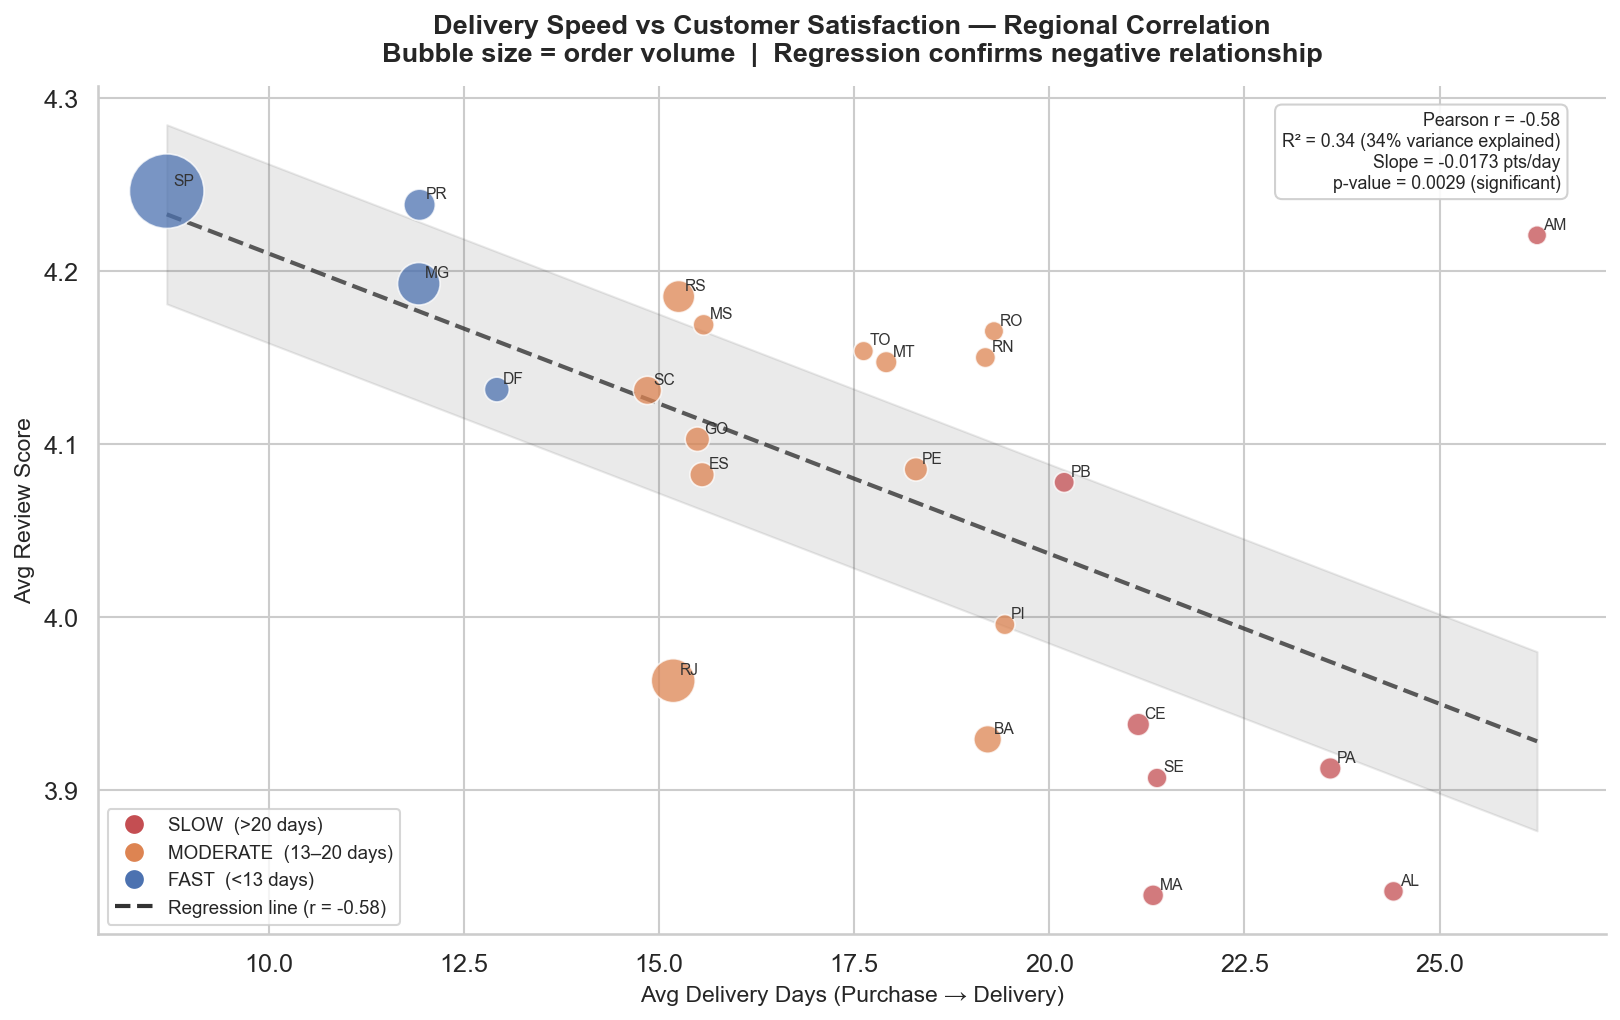

r = -0.58 — moderate negative correlation between delivery days and review score
Every additional day of delivery = 0.0173 point drop in review score


In [44]:
fig, ax = plt.subplots(figsize=(11, 7))

# colour by delivery band
def delivery_color(days):
    if days > 20:   return "#C44E52"
    elif days > 13: return "#DD8452"
    else:           return "#4C72B0"

colors = delivery_corr["avg_delivery_days"].apply(delivery_color)
bubble_sizes = (delivery_corr["total_orders"] /
                delivery_corr["total_orders"].max()) * 1200 + 80

ax.scatter(
    delivery_corr["avg_delivery_days"],
    delivery_corr["avg_review_score"],
    s=bubble_sizes,
    c=colors,
    alpha=0.75,
    edgecolors="white",
    linewidth=0.8,
    zorder=3
)

# label every state
for _, row in delivery_corr.iterrows():
    ax.annotate(
        row["region"],
        xy=(row["avg_delivery_days"], row["avg_review_score"]),
        xytext=(3, 3), textcoords="offset points",
        fontsize=7.5, color="#333333"
    )

# regression line
x_line = np.linspace(delivery_corr["avg_delivery_days"].min(),
                     delivery_corr["avg_delivery_days"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#333333", linewidth=2,
        linestyle="--", alpha=0.8, label=f"Regression line (r = {r_value:.2f})", zorder=2)

# shaded confidence band around regression line
ax.fill_between(x_line,
                y_line - std_err * 10,
                y_line + std_err * 10,
                alpha=0.1, color="#333333", label="Confidence band")

# correlation stats box — top right of chart
stats_text = (
    f"Pearson r = {r_value:.2f}\n"
    f"R² = {r_value**2:.2f} ({r_value**2*100:.0f}% variance explained)\n"
    f"Slope = {slope:.4f} pts/day\n"
    f"p-value = {p_value:.4f} ({'significant' if p_value < 0.05 else 'not significant'})"
)
ax.text(0.97, 0.97, stats_text,
        transform=ax.transAxes,
        fontsize=8.5,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#CCCCCC", alpha=0.9))

# legend for delivery bands
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C44E52',
           markersize=10, label='SLOW  (>20 days)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#DD8452',
           markersize=10, label='MODERATE  (13–20 days)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0',
           markersize=10, label='FAST  (<13 days)'),
    Line2D([0], [0], color='#333333', linewidth=2, linestyle='--',
           label=f'Regression line (r = {r_value:.2f})'),
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower left")

ax.set_xlabel("Avg Delivery Days (Purchase → Delivery)", fontsize=11)
ax.set_ylabel("Avg Review Score", fontsize=11)
ax.set_title(
    "Delivery Speed vs Customer Satisfaction — Regional Correlation\n"
    "Bubble size = order volume  |  Regression confirms negative relationship",
    fontsize=13, fontweight="bold", pad=12
)

plt.tight_layout()
plt.savefig("chart2_delivery_vs_review.png", bbox_inches="tight")
plt.show()

print(f"r = {r_value:.2f} — {strength} correlation between delivery days and review score")
print(f"Every additional day of delivery = {abs(slope):.4f} point drop in review score")

In [45]:
conn = get_connection()

categories = pd.read_sql("""
    SELECT
        t.product_category_name_english          AS category,
        ROUND(SUM(oi.price), 2)                  AS total_revenue,
        ROUND(AVG(r.review_score), 2)            AS avg_review_score,
        COUNT(DISTINCT oi.order_id)              AS total_orders
    FROM olist_order_items oi
    JOIN olist_products p
        ON oi.product_id = p.product_id
    JOIN product_category_name_translation t
        ON p.product_category_name = t.product_category_name
    JOIN olist_order_reviews r
        ON oi.order_id = r.order_id
    JOIN olist_orders o
        ON oi.order_id = o.order_id
        AND o.order_status = 'delivered'
    GROUP BY category
    HAVING SUM(oi.price) > 300000
    ORDER BY total_revenue DESC
""", conn)

conn.close()

# risk flag — same logic as SQL Query 2c
categories["risk_flag"] = categories.apply(
    lambda row: "HIGH RISK" if row["avg_review_score"] < 4.1
                else ("WATCH" if row["avg_review_score"] < 4.3
                else "OK"),
    axis=1
)

print(f"{len(categories)} categories loaded")
print(categories[["category","total_revenue","avg_review_score","risk_flag"]])

C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\1156317800.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  categories = pd.read_sql("""


14 categories loaded
                 category  total_revenue  avg_review_score  risk_flag
0           health_beauty     1228986.81              4.19      WATCH
1           watches_gifts     1160289.57              4.07  HIGH RISK
2          bed_bath_table     1027333.65              3.92  HIGH RISK
3          sports_leisure      954296.99              4.17      WATCH
4   computers_accessories      892279.63              3.98  HIGH RISK
5         furniture_decor      712414.53              3.95  HIGH RISK
6              housewares      613843.72              4.11      WATCH
7              cool_stuff      605088.81              4.19      WATCH
8                    auto      572750.14              4.12      WATCH
9            garden_tools      468477.18              4.08  HIGH RISK
10                   toys      467472.45              4.21      WATCH
11                   baby      397653.69              4.08  HIGH RISK
12              perfumery      389658.85              4.22      WATCH

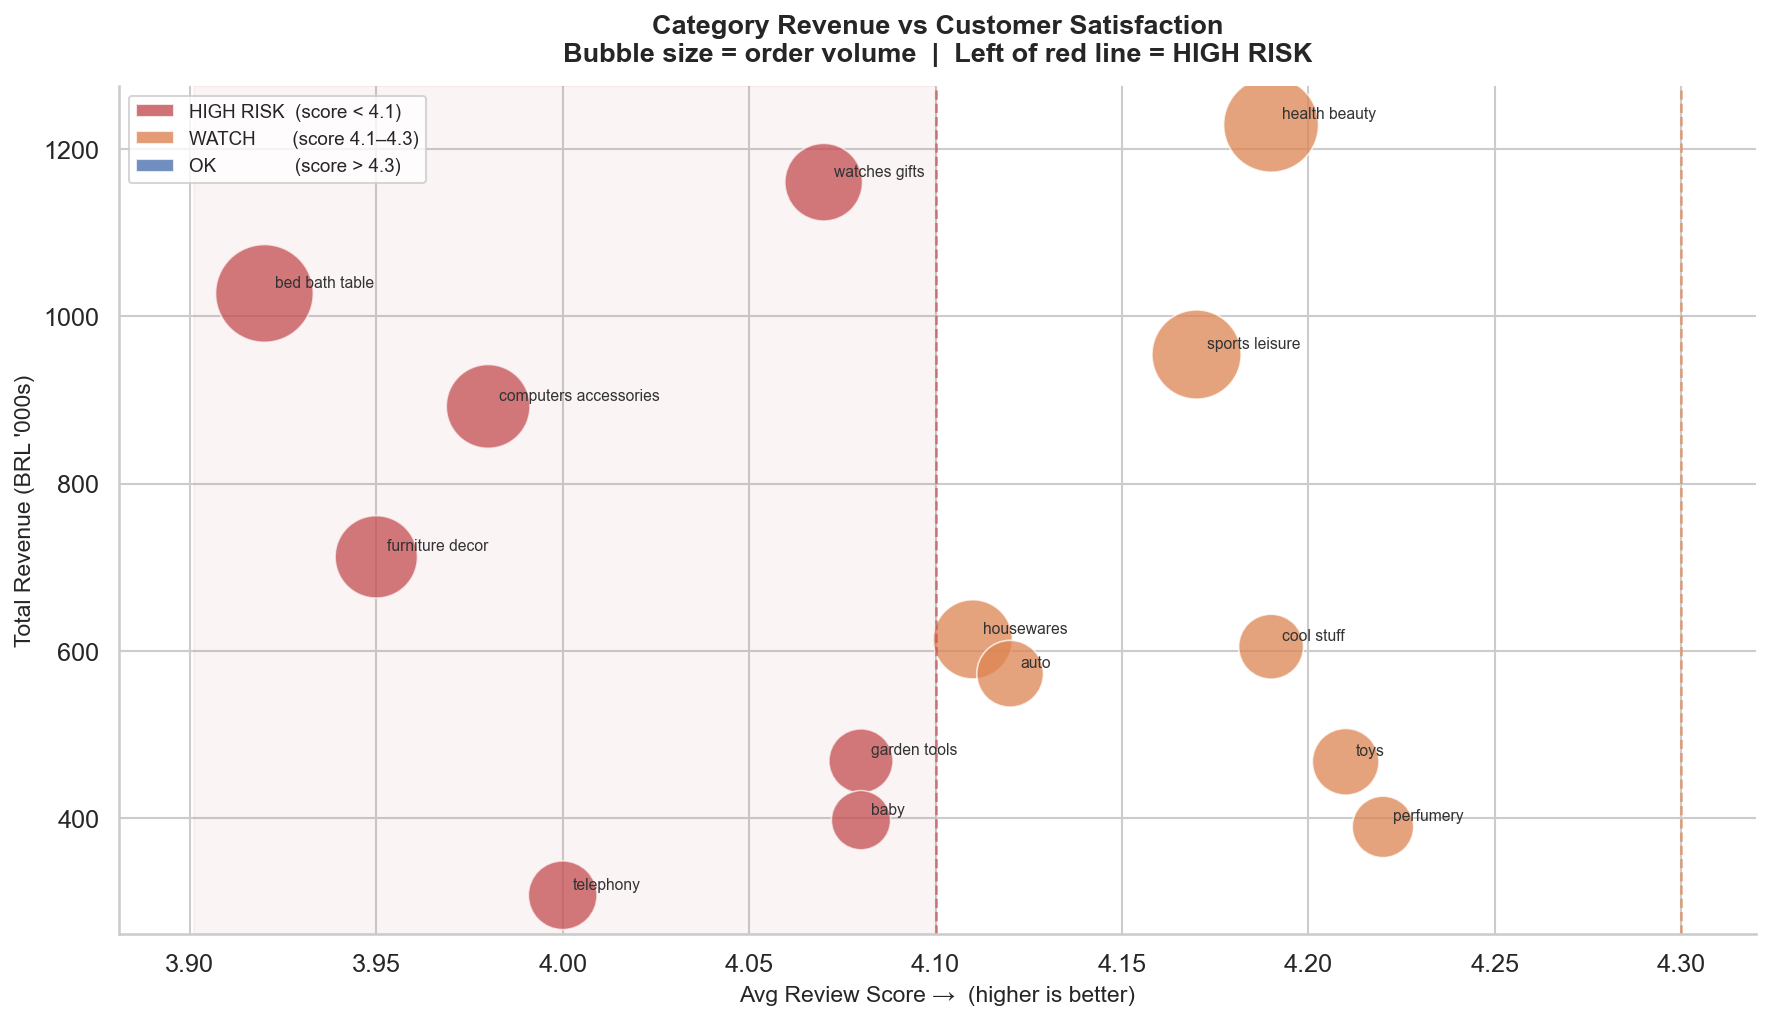

In [46]:
color_map  = {"HIGH RISK": "#C44E52", "WATCH": "#DD8452", "OK": "#4C72B0"}
colors     = categories["risk_flag"].map(color_map)

# bubble size scaled to order volume
bubble_sizes = (categories["total_orders"] /
                categories["total_orders"].max()) * 2000 + 200

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    categories["avg_review_score"],
    categories["total_revenue"] / 1000,
    s=bubble_sizes,
    c=colors,
    alpha=0.75,
    edgecolors="white",
    linewidth=0.8
)

# label every bubble with category name
for _, row in categories.iterrows():
    ax.annotate(
        row["category"].replace("_", " "),   # replace underscores with spaces
        xy=(row["avg_review_score"], row["total_revenue"] / 1000),
        xytext=(5, 3), textcoords="offset points",
        fontsize=7.5, color="#333333"
    )

# vertical line marking the 4.1 HIGH RISK threshold
ax.axvline(x=4.1, color="#C44E52", linewidth=1.2,
           linestyle="--", alpha=0.7, label="HIGH RISK threshold (4.1)")

# vertical line marking the 4.3 WATCH threshold  
ax.axvline(x=4.3, color="#DD8452", linewidth=1.2,
           linestyle="--", alpha=0.7, label="WATCH threshold (4.3)")

# shade the HIGH RISK zone
ax.axvspan(ax.get_xlim()[0], 4.1,
           alpha=0.06, color="#C44E52", label="_nolegend_")

# manual legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#C44E52", alpha=0.8, label="HIGH RISK  (score < 4.1)"),
    Patch(facecolor="#DD8452", alpha=0.8, label="WATCH       (score 4.1–4.3)"),
    Patch(facecolor="#4C72B0", alpha=0.8, label="OK               (score > 4.3)"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="upper left")

ax.set_xlabel("Avg Review Score →  (higher is better)", fontsize=11)
ax.set_ylabel("Total Revenue (BRL '000s)", fontsize=11)
ax.set_title(
    "Category Revenue vs Customer Satisfaction\n"
    "Bubble size = order volume  |  Left of red line = HIGH RISK",
    fontsize=13, fontweight="bold", pad=12
)

plt.tight_layout()
plt.savefig("chart3_category_bubble.png", bbox_inches="tight")
plt.show()

In [47]:

print("\nStory 3 Finding:")
print("4 HIGH RISK categories — watches, bed & bath, computers, furniture.")
print("Combined revenue: ~4M BRL at risk from poor satisfaction scores.")
print("bed_bath_table highest risk: most orders (9,177) + lowest score (3.92).")


Story 3 Finding:
4 HIGH RISK categories — watches, bed & bath, computers, furniture.
Combined revenue: ~4M BRL at risk from poor satisfaction scores.
bed_bath_table highest risk: most orders (9,177) + lowest score (3.92).


In [48]:
conn = get_connection()

cohorts = pd.read_sql("""
    WITH customer_orders AS (
        SELECT
            c.customer_unique_id,
            o.order_id,
            o.order_purchase_timestamp
        FROM olist_orders o
        JOIN olist_customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
    ),
    customer_cohorts AS (
        SELECT
            customer_unique_id,
            DATE_FORMAT(MIN(order_purchase_timestamp), '%Y-%m') AS cohort_month,
            COUNT(DISTINCT order_id)                            AS total_orders
        FROM customer_orders
        GROUP BY customer_unique_id
    )
    SELECT
        cohort_month,
        COUNT(customer_unique_id)                               AS total_customers,
        SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END)      AS repeat_customers,
        ROUND(SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END)
            * 100.0 / COUNT(customer_unique_id), 2)            AS repeat_rate_pct
    FROM customer_cohorts
    GROUP BY cohort_month
    HAVING COUNT(customer_unique_id) >= 100    -- exclude tiny cohorts
    ORDER BY cohort_month
""", conn)

conn.close()

# exclude 2016 — too early, data is noisy
cohorts = cohorts[cohorts["cohort_month"] >= "2017-01"]

# exclude late 2018 cohorts — dataset cuts off before repeat window closes
cohorts = cohorts[cohorts["cohort_month"] <= "2018-06"]

print(cohorts[["cohort_month", "total_customers",
               "repeat_customers", "repeat_rate_pct"]].to_string(index=False))

C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\3850481686.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cohorts = pd.read_sql("""


cohort_month  total_customers  repeat_customers  repeat_rate_pct
     2017-01              717              52.0             7.25
     2017-02             1628              66.0             4.05
     2017-03             2503             121.0             4.83
     2017-04             2256             102.0             4.52
     2017-05             3451             182.0             5.27
     2017-06             3037             161.0             5.30
     2017-07             3752             175.0             4.66
     2017-08             4057             191.0             4.71
     2017-09             4004             180.0             4.50
     2017-10             4328             160.0             3.70
     2017-11             7060             223.0             3.16
     2017-12             5338             139.0             2.60
     2018-01             6842             208.0             3.04
     2018-02             6288             236.0             3.75
     2018-03             

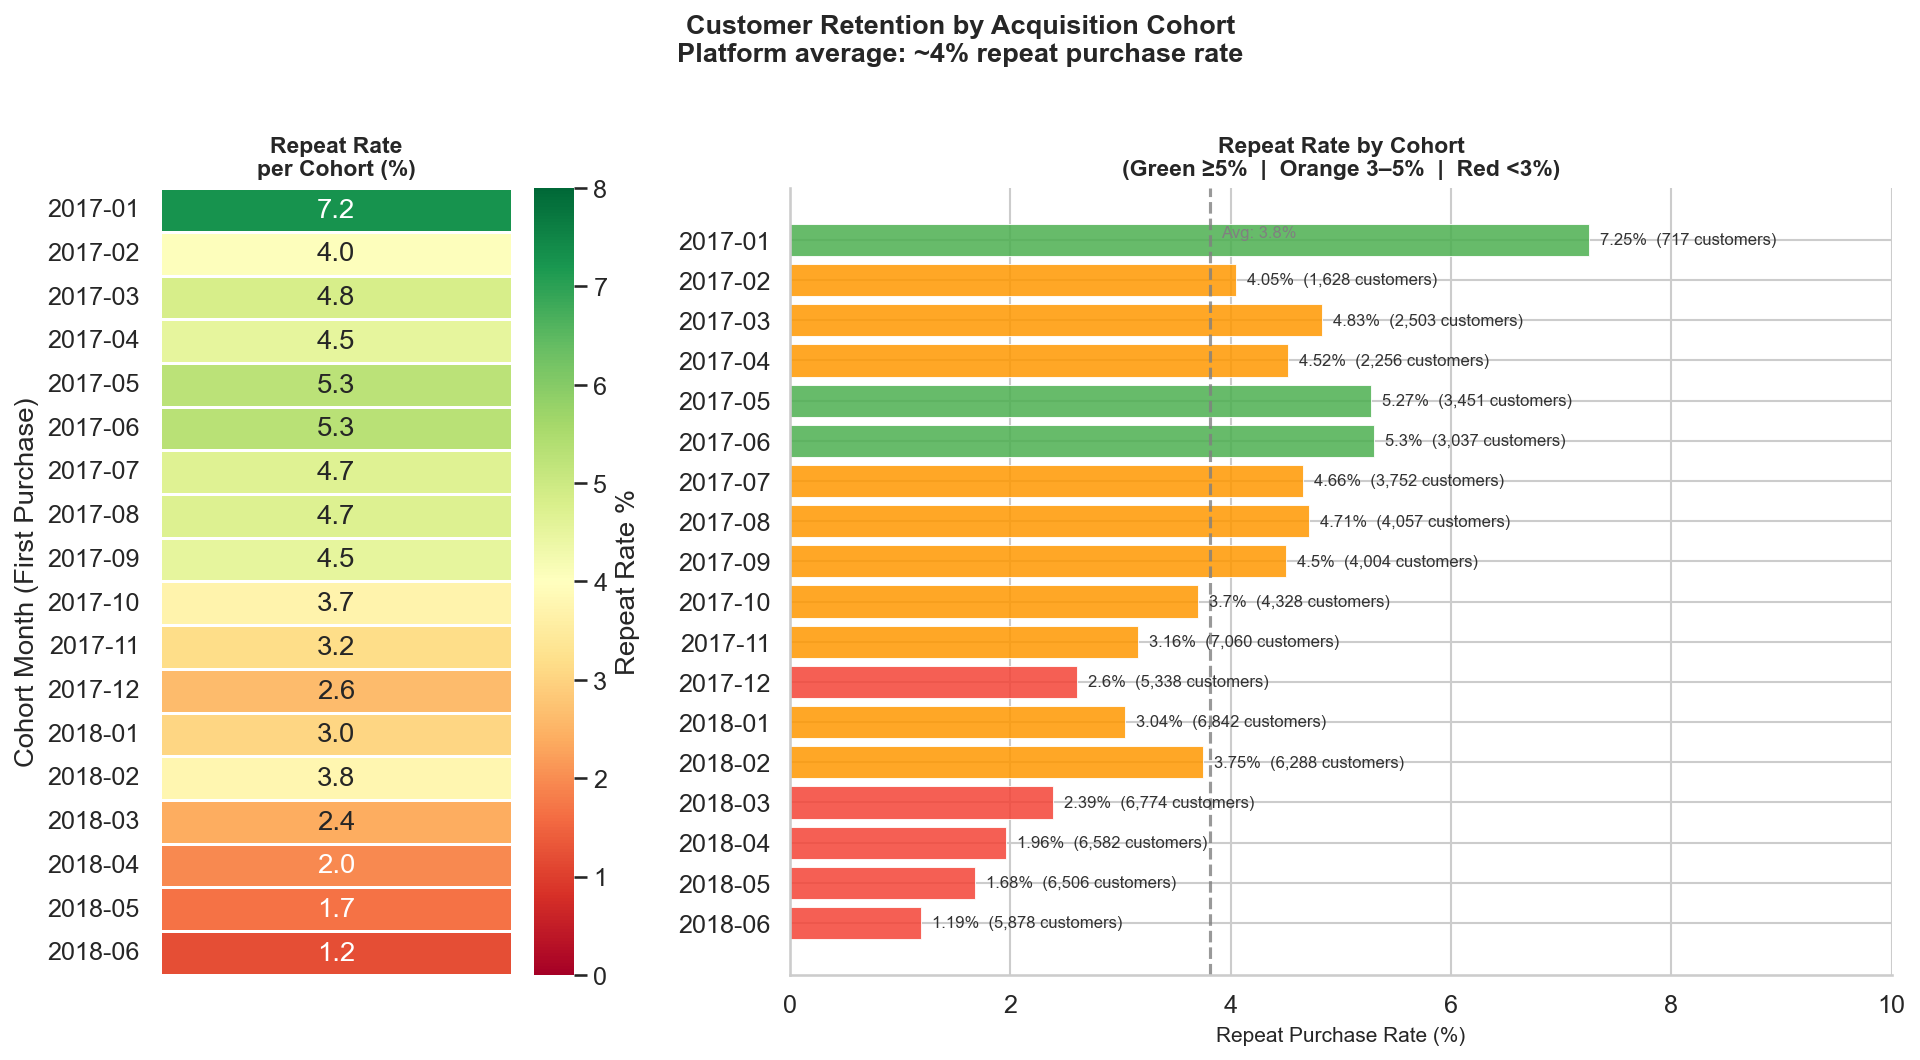

In [49]:
# reshape data for heatmap — needs a 2D grid structure
# we'll create a single-column heatmap showing repeat rate per cohort month
heatmap_data = cohorts.set_index("cohort_month")[["repeat_rate_pct"]]

fig, (ax_heat, ax_bar) = plt.subplots(
    1, 2,                            # 1 row, 2 columns — heatmap left, bar chart right
    figsize=(13, 7),
    gridspec_kw={"width_ratios": [1, 2.5]}   # bar chart gets more width
)

# --- LEFT PANEL: heatmap ---
sns.heatmap(
    heatmap_data,
    ax=ax_heat,
    cmap="RdYlGn",                   # red = low retention, green = high
    annot=True,                      # show actual % values inside cells
    fmt=".1f",                       # one decimal place
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Repeat Rate %"},
    vmin=0, vmax=8                   # fix colour scale — 0% to 8% range
)
ax_heat.set_title("Repeat Rate\nper Cohort (%)",
                  fontsize=11, fontweight="bold")
ax_heat.set_xlabel("")
ax_heat.set_ylabel("Cohort Month (First Purchase)")
ax_heat.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

# --- RIGHT PANEL: bar chart with trend ---
bar_colors = [
    "#4CAF50" if r >= 5 else         # green — above 5%
    "#FF9800" if r >= 3 else         # orange — 3-5%
    "#F44336"                        # red — below 3%
    for r in cohorts["repeat_rate_pct"]
]

ax_bar.barh(
    cohorts["cohort_month"],
    cohorts["repeat_rate_pct"],
    color=bar_colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5
)

# label each bar with exact % and customer count
for _, row in cohorts.iterrows():
    ax_bar.text(
        row["repeat_rate_pct"] + 0.1,
        row["cohort_month"],
        f"{row['repeat_rate_pct']}%  ({row['total_customers']:,} customers)",
        va="center", fontsize=8, color="#333333"
    )

# vertical line — platform average
avg_rate = cohorts["repeat_rate_pct"].mean()
ax_bar.axvline(x=avg_rate, color="gray", linewidth=1.5,
               linestyle="--", alpha=0.8)
ax_bar.text(avg_rate + 0.1, cohorts["cohort_month"].iloc[0],
            f"Avg: {avg_rate:.1f}%",
            fontsize=8, color="gray", va="bottom")

ax_bar.set_xlabel("Repeat Purchase Rate (%)", fontsize=10)
ax_bar.set_title("Repeat Rate by Cohort\n(Green ≥5%  |  Orange 3–5%  |  Red <3%)",
                 fontsize=11, fontweight="bold")
ax_bar.set_xlim(0, 10)
ax_bar.invert_yaxis()                # most recent cohort at bottom

plt.suptitle(
    "Customer Retention by Acquisition Cohort\n"
    "Platform average: ~4% repeat purchase rate",
    fontsize=13, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("chart4_retention_heatmap.png", bbox_inches="tight")
plt.show()


In [50]:
print("\nStory 4 Finding:")
print(f"Platform avg repeat rate: {avg_rate:.1f}% — 96% of customers never return.")
print("Peak retention: May-Jun 2017 at ~5.3% during hypergrowth phase.")
print("Consistent decline through 2018 — retention worsening as platform scaled.")
print("Direct link to Stories 2 & 3 — poor delivery + category dissatisfaction")
print("are the operational drivers of this retention collapse.")


Story 4 Finding:
Platform avg repeat rate: 3.8% — 96% of customers never return.
Peak retention: May-Jun 2017 at ~5.3% during hypergrowth phase.
Consistent decline through 2018 — retention worsening as platform scaled.
Direct link to Stories 2 & 3 — poor delivery + category dissatisfaction
are the operational drivers of this retention collapse.


In [51]:
conn = get_connection()

# --- export 1: monthly orders ---
monthly_orders = pd.read_sql("""
    SELECT
        DATE_FORMAT(order_purchase_timestamp, '%Y-%m') AS order_month,
        COUNT(order_id)                                AS total_orders,
        COUNT(order_id) / LAG(COUNT(order_id)) OVER (
            ORDER BY DATE_FORMAT(order_purchase_timestamp,'%Y-%m')
        ) * 100 - 100                                  AS mom_growth_pct
    FROM olist_orders
    WHERE order_status = 'delivered'
      AND order_purchase_timestamp >= '2017-01-01'
    GROUP BY order_month
    ORDER BY order_month
""", conn)
monthly_orders.to_csv("powerbi_monthly_orders.csv", index=False)
print("✓ monthly_orders exported")

# --- export 2: category performance ---
category_perf = pd.read_sql("""
    SELECT
        t.product_category_name_english     AS category,
        ROUND(SUM(oi.price), 2)             AS total_revenue,
        COUNT(DISTINCT oi.order_id)         AS total_orders,
        ROUND(AVG(r.review_score), 2)       AS avg_review_score,
        CASE
            WHEN AVG(r.review_score) < 4.1  THEN 'HIGH RISK'
            WHEN AVG(r.review_score) < 4.3  THEN 'WATCH'
            ELSE 'OK'
        END                                 AS risk_flag
    FROM olist_order_items oi
    JOIN olist_products p
        ON oi.product_id = p.product_id
    JOIN product_category_name_translation t
        ON p.product_category_name = t.product_category_name
    JOIN olist_order_reviews r
        ON oi.order_id = r.order_id
    JOIN olist_orders o
        ON oi.order_id = o.order_id
        AND o.order_status = 'delivered'
    GROUP BY category
""", conn)
category_perf.to_csv("powerbi_category_perf.csv", index=False)
print("✓ category_perf exported")

# --- export 3: regional delivery ---
regional_delivery = pd.read_sql("""
    SELECT
        c.customer_state                                      AS region,
        COUNT(DISTINCT o.order_id)                           AS total_orders,
        ROUND(AVG(DATEDIFF(
            o.order_delivered_customer_date,
            o.order_purchase_timestamp)), 1)                 AS avg_delivery_days,
        ROUND(AVG(r.review_score), 2)                        AS avg_review_score,
        ROUND(SUM(CASE
            WHEN o.order_delivered_customer_date >
                 o.order_estimated_delivery_date
            THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1)       AS pct_late_orders,
        CASE
            WHEN AVG(DATEDIFF(
                o.order_delivered_customer_date,
                o.order_purchase_timestamp)) > 20  THEN 'SLOW'
            WHEN AVG(DATEDIFF(
                o.order_delivered_customer_date,
                o.order_purchase_timestamp)) > 13  THEN 'MODERATE'
            ELSE 'FAST'
        END                                                   AS delivery_band
    FROM olist_orders o
    JOIN olist_customers c      ON o.customer_id = c.customer_id
    JOIN olist_order_reviews r  ON o.order_id    = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY c.customer_state
""", conn)
regional_delivery.to_csv("powerbi_regional_delivery.csv", index=False)
print("✓ regional_delivery exported")

# --- export 4: seller pareto ---
seller_pareto = pd.read_sql("""
    SELECT
        oi.seller_id,
        s.seller_state,
        ROUND(SUM(oi.price), 2)                              AS seller_revenue,
        COUNT(DISTINCT oi.order_id)                          AS total_orders,
        ROUND(SUM(oi.price) * 100.0 /
            SUM(SUM(oi.price)) OVER (), 2)                   AS revenue_share_pct,
        ROUND(SUM(SUM(oi.price)) OVER (
            ORDER BY SUM(oi.price) DESC) * 100.0 /
            SUM(SUM(oi.price)) OVER (), 2)                   AS cumulative_revenue_pct
    FROM olist_order_items oi
    JOIN olist_sellers s ON oi.seller_id = s.seller_id
    GROUP BY oi.seller_id, s.seller_state
    ORDER BY seller_revenue DESC
""", conn)
seller_pareto.to_csv("powerbi_seller_pareto.csv", index=False)
print("✓ seller_pareto exported")

# --- export 5: payment analysis ---
payment_analysis = pd.read_sql("""
    SELECT
        op.payment_type,
        COUNT(DISTINCT op.order_id)              AS total_orders,
        ROUND(AVG(op.payment_value), 2)          AS avg_order_value,
        ROUND(SUM(op.payment_value), 2)          AS total_revenue,
        ROUND(AVG(op.payment_installments), 1)   AS avg_installments
    FROM olist_order_payments op
    JOIN olist_orders o ON op.order_id = o.order_id
        AND o.order_status = 'delivered'
    WHERE op.payment_type != 'not_defined'
    GROUP BY op.payment_type
    ORDER BY total_revenue DESC
""", conn)
payment_analysis.to_csv("powerbi_payment_analysis.csv", index=False)
print("✓ payment_analysis exported")

# --- export 6: cohort retention ---
cohort_retention = pd.read_sql("""
    WITH customer_orders AS (
        SELECT c.customer_unique_id, o.order_id, o.order_purchase_timestamp
        FROM olist_orders o
        JOIN olist_customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
    ),
    customer_cohorts AS (
        SELECT customer_unique_id,
            DATE_FORMAT(MIN(order_purchase_timestamp), '%Y-%m') AS cohort_month,
            COUNT(DISTINCT order_id)                            AS total_orders
        FROM customer_orders
        GROUP BY customer_unique_id
    )
    SELECT
        cohort_month,
        COUNT(customer_unique_id)                               AS total_customers,
        SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END)      AS repeat_customers,
        ROUND(SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END)
            * 100.0 / COUNT(customer_unique_id), 2)            AS repeat_rate_pct
    FROM customer_cohorts
    WHERE cohort_month >= '2017-01'
    GROUP BY cohort_month
    HAVING COUNT(customer_unique_id) >= 100
    ORDER BY cohort_month
""", conn)
cohort_retention.to_csv("powerbi_cohort_retention.csv", index=False)
print("✓ cohort_retention exported")

conn.close()
print("\nAll 6 Power BI datasets exported to your notebooks folder")

C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\68813977.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_orders = pd.read_sql("""
C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\68813977.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  category_perf = pd.read_sql("""


✓ monthly_orders exported
✓ category_perf exported


C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\68813977.py:48: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  regional_delivery = pd.read_sql("""


✓ regional_delivery exported


C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\68813977.py:80: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  seller_pareto = pd.read_sql("""


✓ seller_pareto exported


C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\68813977.py:100: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  payment_analysis = pd.read_sql("""


✓ payment_analysis exported


C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\68813977.py:118: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cohort_retention = pd.read_sql("""


✓ cohort_retention exported

All 6 Power BI datasets exported to your notebooks folder


In [52]:
import pymysql
import pandas as pd

conn = pymysql.connect(
    host="localhost",
    user="root",
    password="valorant1",
    database="olist_analysis"
)

# pull directly from sql with the exact same CASE WHEN logic
category_perf = pd.read_sql("""
    SELECT
        t.product_category_name_english          AS category,
        ROUND(SUM(oi.price), 2)                  AS total_revenue,
        COUNT(DISTINCT oi.order_id)              AS total_orders,
        ROUND(AVG(r.review_score), 2)            AS avg_review_score,
        CASE
            WHEN SUM(oi.price) > 500000
             AND AVG(r.review_score) < 4.1  THEN 'HIGH RISK'
            WHEN SUM(oi.price) > 500000
             AND AVG(r.review_score) < 4.3  THEN 'WATCH'
            ELSE 'OK'
        END                                      AS risk_flag
    FROM olist_order_items oi
    JOIN olist_products p
        ON oi.product_id = p.product_id
    JOIN product_category_name_translation t
        ON p.product_category_name = t.product_category_name
    JOIN olist_order_reviews r
        ON oi.order_id = r.order_id
    JOIN olist_orders o
        ON oi.order_id = o.order_id
        AND o.order_status = 'delivered'
    GROUP BY category
    ORDER BY total_revenue DESC
""", conn)

conn.close()

# verify flags before saving
print(category_perf[category_perf['risk_flag'] == 'HIGH RISK'])
print("\nFlag counts:")
print(category_perf['risk_flag'].value_counts())

# overwrite the old csv
category_perf.to_csv("powerbi_category_perf.csv", index=False)
print("\nCSV re-exported with correct flags")

C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\3880813757.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  category_perf = pd.read_sql("""


                category  total_revenue  total_orders  avg_review_score  \
1          watches_gifts     1160289.57          5454              4.07   
2         bed_bath_table     1027333.65          9177              3.92   
4  computers_accessories      892279.63          6499              3.98   
5        furniture_decor      712414.53          6260              3.95   

   risk_flag  
1  HIGH RISK  
2  HIGH RISK  
4  HIGH RISK  
5  HIGH RISK  

Flag counts:
risk_flag
OK           62
WATCH         5
HIGH RISK     4
Name: count, dtype: int64

CSV re-exported with correct flags


In [53]:
conn = pymysql.connect(
    host="localhost",
    user="root",
    password="valorant1",
    database="olist_analysis"
)

regional = pd.read_sql("""
    SELECT
        c.customer_state                                      AS region,
        COUNT(DISTINCT o.order_id)                           AS total_orders,
        ROUND(AVG(DATEDIFF(
            o.order_delivered_customer_date,
            o.order_purchase_timestamp)), 1)                 AS avg_delivery_days,
        ROUND(AVG(r.review_score), 2)                        AS avg_review_score,
        ROUND(SUM(CASE
            WHEN o.order_delivered_customer_date >
                 o.order_estimated_delivery_date
            THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1)       AS pct_late_orders,
        CASE
            WHEN AVG(DATEDIFF(
                o.order_delivered_customer_date,
                o.order_purchase_timestamp)) > 20  THEN 'SLOW'
            WHEN AVG(DATEDIFF(
                o.order_delivered_customer_date,
                o.order_purchase_timestamp)) > 13  THEN 'MODERATE'
            ELSE 'FAST'
        END                                                   AS delivery_band
    FROM olist_orders o
    JOIN olist_customers c      ON o.customer_id = c.customer_id
    JOIN olist_order_reviews r  ON o.order_id    = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY c.customer_state
""", conn)

conn.close()

# add country and full state name columns
# power bi uses these to unambiguously locate brazilian states on the map
regional['country'] = 'Brazil'

# map state codes to full portuguese names — power bi recognises these
state_names = {
    'SP': 'São Paulo',        'RJ': 'Rio de Janeiro',
    'MG': 'Minas Gerais',     'RS': 'Rio Grande do Sul',
    'PR': 'Paraná',           'SC': 'Santa Catarina',
    'BA': 'Bahia',            'GO': 'Goiás',
    'ES': 'Espírito Santo',   'PE': 'Pernambuco',
    'CE': 'Ceará',            'PA': 'Pará',
    'MT': 'Mato Grosso',      'MS': 'Mato Grosso do Sul',
    'MA': 'Maranhão',         'RN': 'Rio Grande do Norte',
    'PB': 'Paraíba',          'AL': 'Alagoas',
    'PI': 'Piauí',            'SE': 'Sergipe',
    'TO': 'Tocantins',        'RO': 'Rondônia',
    'AM': 'Amazonas',         'AC': 'Acre',
    'AP': 'Amapá',            'RR': 'Roraima',
    'DF': 'Distrito Federal'
}

regional['state_name'] = regional['region'].map(state_names)

print(regional[['region', 'state_name', 'country', 
                'avg_delivery_days', 'avg_review_score']].to_string(index=False))

regional.to_csv("powerbi_regional_delivery.csv", index=False)
print("\nCSV re-exported with country and state_name columns")

C:\Users\kumar\AppData\Local\Temp\ipykernel_119448\1919996199.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  regional = pd.read_sql("""


region          state_name country  avg_delivery_days  avg_review_score
    AC                Acre  Brazil               21.0              4.09
    AL             Alagoas  Brazil               24.4              3.84
    AM            Amazonas  Brazil               26.2              4.22
    AP               Amapá  Brazil               27.1              4.24
    BA               Bahia  Brazil               19.2              3.93
    CE               Ceará  Brazil               21.1              3.94
    DF    Distrito Federal  Brazil               12.9              4.13
    ES      Espírito Santo  Brazil               15.6              4.08
    GO               Goiás  Brazil               15.5              4.10
    MA            Maranhão  Brazil               21.3              3.84
    MG        Minas Gerais  Brazil               11.9              4.19
    MS  Mato Grosso do Sul  Brazil               15.6              4.17
    MT         Mato Grosso  Brazil               17.9           